# Generation of Fake Images with Bridger Insight CAPTCHA Digits

Many websites require human users to read CAPTCHA images and put the recognized text, generally to differentiate between human visitors and robotic agents. For example, the Bridger Insight website requires human users to do this, when they fail to log in by typing incorrect account/password information. From the developer's point of view, this kind of CAPTCHAs prevents from developing seamless automation. 
Object detection models can be used to recognize text from the CAPTCHA images. 
This code generates random digits, customized for Bridger Insight CAPTCHA images. Different font and background colors, along with noise-like random stripes or dots, make the detection model robust in recognizing the digits in the images.


Bomsoo Kim

03/31/2023

In [1]:
import numpy as np
import random
import cv2
import copy
import matplotlib.pyplot as plt
from PIL import Image

GRID_W, GRID_H = 6, 2
UPIXEL_W, UPIXEL_H = 32, 32
LABELS = ['0','1','2','3','4','5','6','7','8','9']
IMAGE_W, IMAGE_H = GRID_W * UPIXEL_W, GRID_H * UPIXEL_H

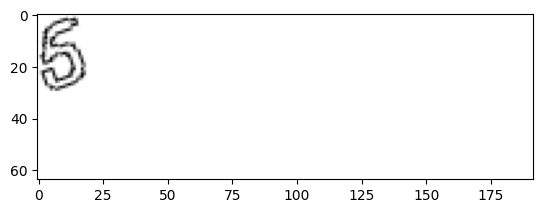

In [2]:
def generate_one_digit_pixels(
    digit = '1',
    font = cv2.FONT_HERSHEY_SIMPLEX,
    fontScale = 1,
    angle = 0, # rotation angle
    # angle = +45, # rotation angle
    rgb_clamp = [1.0, 1.0, 1.0],
    # rgb_clamp = [9.0, 9.0, 1.0],
    clamp_func = lambda x, clamp=1.0: min(x/clamp, 1.0),
):
    bottomLeftCornerOfText = (10,40)
    fontColor              = (0,0,0)
    thickness              = 2
    lineType               = 2

    #--- Create a black image ---
    # img = np.full((60,170,3), 255, np.uint8)
    img = np.full((50,50,3), 255, np.uint8)

    #--- write text ---
    cv2.putText(img, digit, bottomLeftCornerOfText, font, fontScale, fontColor, thickness, lineType)

    img = cv2.Canny(img, 50, 200, apertureSize=5, L2gradient=False) # edge detection
    img = np.expand_dims(img, axis=-1) # convert into RGB format
    img = np.repeat(img, repeats=3, axis=-1) # convert into RGB format
#     print(img.shape, img.dtype)

    #--- rotate image: https://stackoverflow.com/questions/9041681/opencv-python-rotate-image-by-x-degrees-around-specific-point
    image_center = tuple(np.array(img.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    img = cv2.warpAffine(img, rot_mat, img.shape[1::-1], flags=cv2.INTER_LINEAR)

    #--- extract coordinates ---
    coords_raw = {}
    y_min, y_max, x_min, x_max = float('inf'), float('-inf'), float('inf'), float('-inf')
    c_max = float('-inf')
    for y in range(len(img)):
        for x in range(len(img[0])):
            if sum(img[y][x]) > 0:
                coords_raw[(y,x)] = copy.deepcopy(img[y][x])
                y_min = min(y_min, y-1) # 1 margin for bbox
                y_max = max(y_max, y+1) # 1 margin for bbox
                x_min = min(x_min, x-1) # 1 margin for bbox
                x_max = max(x_max, x+1) # 1 margin for bbox
                c_max = max(c_max, max(img[y][x]))
#     print(y_min, y_max, x_min, x_max, c_max, len(coords_raw))
    # print(coords_raw)

    #--- chop image ---
    coords = {}
    for (y,x), (r,g,b) in coords_raw.items():
    #     coords[(y - y_min, x - x_min)] = [r, g, b]
        coords[(y - y_min, x - x_min)] = [
            255 - int(c_max*clamp_func(r/c_max, rgb_clamp[0])), # 255: invert color
            255 - int(c_max*clamp_func(g/c_max, rgb_clamp[1])), # 255: invert color
            255 - int(c_max*clamp_func(b/c_max, rgb_clamp[2])), # 255: invert color
        ]
    y0, y1, x0, x1 = 0, y_max - y_min, 0, x_max - x_min

    return coords, (x0, y0, x1, y1)

if __name__=='__main__':
    coords, (x0, y0, x1, y1) = generate_one_digit_pixels(
        digit = '5',
#         font = cv2.FONT_HERSHEY_SIMPLEX,
#         font = cv2.FONT_HERSHEY_PLAIN,
#         font = cv2.FONT_HERSHEY_DUPLEX,
#         font = cv2.FONT_HERSHEY_COMPLEX,
#         font = cv2.FONT_HERSHEY_TRIPLEX,
#         font = cv2.FONT_HERSHEY_COMPLEX_SMALL,
#         font = cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
        font = cv2.FONT_HERSHEY_SCRIPT_COMPLEX,
    #     angle = 0, # rotation angle
    #     angle = +45, # rotation angle
        angle = +20, # rotation angle
        rgb_clamp = [1.0, 1.0, 1.0],
    #     rgb_clamp = [0.6, 1.6, 1.6],
        # rgb_clamp = [9.0, 9.0, 1.0],
        clamp_func = lambda x, clamp=1.0: min(x/clamp, 1.0),
    )

    #--- create chopped image ---
    # img_new = np.full((y1 - y0 + 1, x1 - x0 + 1, 3), 255, np.uint8) # white board
    img_new = np.full((GRID_H*UPIXEL_H, GRID_W*UPIXEL_W, 3), 255, np.uint8) # white board
    for (y,x), rgb in coords.items():
        img_new[y][x] = rgb

    #--- show image ----
    plt.imshow(Image.fromarray(img_new, 'RGB'))
    plt.show()

[{'digit': '4', 'bbox': (117.5, 18.5, 27, 35)}, {'digit': '8', 'bbox': (150.0, 38.5, 22, 27)}, {'digit': '8', 'bbox': (35.5, 8.5, 23, 23)}, {'digit': '2', 'bbox': (95.0, 17.0, 36, 40)}, {'digit': '7', 'bbox': (156.0, 8.0, 18, 24)}, {'digit': '3', 'bbox': (165.0, 47.5, 38, 35)}, {'digit': '3', 'bbox': (117.5, 60.0, 25, 34)}, {'digit': '9', 'bbox': (81.0, 50.5, 20, 21)}, {'digit': '0', 'bbox': (18.5, 3.5, 27, 31)}, {'digit': '9', 'bbox': (15.0, 33.5, 30, 35)}]


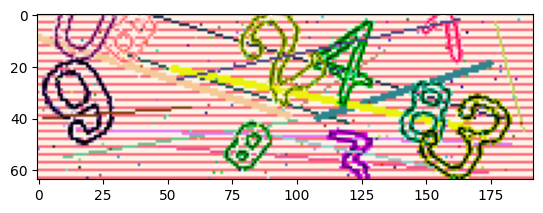

[{'digit': '5', 'bbox': (49.5, 31.5, 29, 33)}, {'digit': '4', 'bbox': (31.0, 47.0, 24, 34)}, {'digit': '4', 'bbox': (74.5, 40.5, 19, 23)}, {'digit': '7', 'bbox': (140.0, 30.0, 20, 28)}, {'digit': '2', 'bbox': (78.0, 8.5, 24, 27)}, {'digit': '8', 'bbox': (164.0, 16.5, 20, 25)}, {'digit': '5', 'bbox': (53.5, 2.5, 25, 27)}, {'digit': '8', 'bbox': (140.0, 55.5, 28, 35)}, {'digit': '7', 'bbox': (117.5, 53.0, 23, 30)}, {'digit': '0', 'bbox': (24.5, 4.5, 19, 25)}]


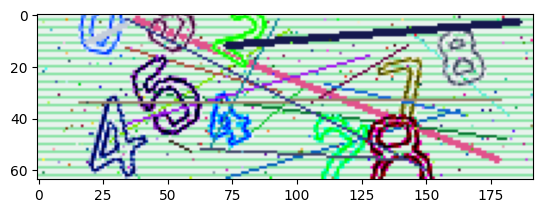

[]


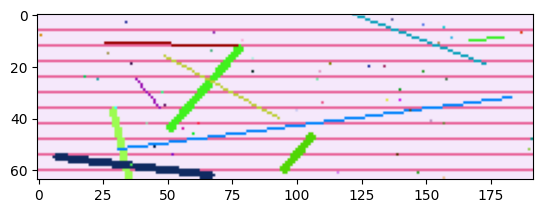

[{'digit': '9', 'bbox': (17.0, 50.0, 26, 30)}, {'digit': '2', 'bbox': (99.0, 59.5, 20, 27)}, {'digit': '2', 'bbox': (190.0, 46.5, 28, 33)}]


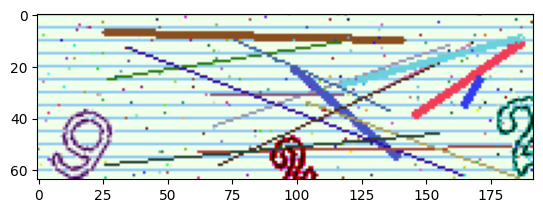

[{'digit': '9', 'bbox': (169.0, 39.5, 28, 31)}, {'digit': '4', 'bbox': (111.0, 9.0, 20, 26)}, {'digit': '9', 'bbox': (148.5, 50.0, 17, 24)}, {'digit': '2', 'bbox': (92.5, 49.0, 25, 22)}, {'digit': '2', 'bbox': (32.5, 16.5, 17, 25)}, {'digit': '7', 'bbox': (26.5, 10.0, 17, 22)}, {'digit': '7', 'bbox': (71.0, 3.0, 24, 28)}, {'digit': '9', 'bbox': (99.5, 38.0, 23, 28)}, {'digit': '7', 'bbox': (60.0, 50.5, 22, 35)}, {'digit': '9', 'bbox': (8.5, 38.5, 19, 25)}, {'digit': '6', 'bbox': (128.0, 21.0, 30, 36)}, {'digit': '5', 'bbox': (188.0, 27.5, 34, 35)}]


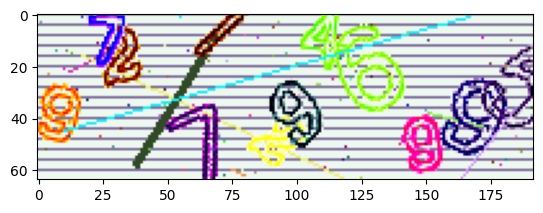

In [3]:
def draw_strips(img, starting=0, interval=4):
    color = (random.randint(100,255), random.randint(100,255), random.randint(100,255))
    yy = starting
    while yy <= IMAGE_H:
        start_point = (0, yy)
        end_point = (IMAGE_W, yy)
        img = cv2.line(img, start_point, end_point, color, thickness=1)
        yy += interval
    return img        

def draw_random_points(img, num=1):
    for _ in range(num):
        x = random.randint(0, IMAGE_W - 1)
        y = random.randint(0, IMAGE_H - 1)
        img[y][x][0] = random.randint(0,255)
        img[y][x][1] = random.randint(0,255)
        img[y][x][2] = random.randint(0,255)
    return img
    
def draw_random_lines(img, num=1):
    for _ in range(num):
        start_point = (random.randint(0,IMAGE_W), random.randint(0,IMAGE_H))
        end_point = (random.randint(0,IMAGE_W), random.randint(0,IMAGE_H))
        color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))
        thickness = random.sample([1,1,1,2], 1)[0]
        img = cv2.line(img, start_point, end_point, color, thickness)
    return img

def create_random_sample():
    grid_points = [(x,y) for x in range(GRID_W) for y in range(GRID_H)]

#     img = Image.fromarray(np.full((IMAGE_H, IMAGE_W, 3), 255, 'uint8')) # initialize image
    img = np.full((IMAGE_H, IMAGE_W, 3), 255, 'uint8') # initialize image
    img[...,0] = random.randint(230, 255)
    img[...,1] = random.randint(230, 255)
    img[...,2] = random.randint(230, 255)
    
    #--- draw strips -----------
    interval = random.randint(3,6)
    starting = random.randint(0,interval)
    img = draw_strips(img, starting=starting, interval=interval)
    
    #--- draw random points ----
    img = draw_random_points(img, num=random.randint(1,150))
    
    #--- draw random lines ----
    img = draw_random_lines(img, num=random.randint(1,10))
    
    #--- draw digits ----------
    num_digits = random.choice(range(0, len(grid_points) + 1))
    random_grid_points = random.sample(grid_points, k=num_digits)
    
    info = []
    for j in range(num_digits):
        digit = random.choice(LABELS)
        gx, gy = random_grid_points.pop()
        dx, dy = random.uniform(0.01, 0.99), random.uniform(0.01, 0.99)
        
        xc, yc = (gx + dx) * UPIXEL_W, (gy + dy) * UPIXEL_H # center point

        #--- generate a digit ----------------------------
        coords, (x0, y0, x1, y1) = generate_one_digit_pixels(
            digit = digit,
            font = random.choice([
                cv2.FONT_HERSHEY_SIMPLEX,
#                 cv2.FONT_HERSHEY_PLAIN,
                cv2.FONT_HERSHEY_DUPLEX,
                cv2.FONT_HERSHEY_COMPLEX,
                cv2.FONT_HERSHEY_TRIPLEX,
#                 cv2.FONT_HERSHEY_COMPLEX_SMALL,
                cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,
                cv2.FONT_HERSHEY_SCRIPT_COMPLEX,
            ]),
#             fontScale = 1,
            fontScale = random.uniform(0.7, 1.5),
#             angle = 0, # rotation angle
            angle = random.uniform(-45, 45), # rotation angle
#             rgb_clamp = [1.0, 1.0, 1.0],
            rgb_clamp = [random.uniform(-0.2, 1.5), random.uniform(-0.2, 1.5), random.uniform(-0.2, 1.5)],
        )
        
        #--- recalculate coordinates ----------------------
        x_off = int(xc - (x0 + x1)/2.0)
        y_off = int(yc - (y0 + y1)/2.0)
        
        x0, y0, x1, y1 = x0 + x_off, y0 + y_off, x1 + x_off, y1 + y_off # recalculate
        bbox = ((x0 + x1)/2.0, (y0 + y1)/2.0, (x1 - x0), (y1 - y0))
        
        
        #--- draw digit -----------------------------------
        for (y,x), rgb in coords.items():
            xx, yy = x + x_off, y + y_off
            if 0 <= yy < IMAGE_H and 0 <= xx < IMAGE_W:
                # img[yy][xx] = rgb
                img[yy][xx] = [max(0,min(255,c)) for c in rgb]

        #--- save output -------------------
        info.append({'digit':digit, 'bbox':bbox})

    #--- draw random lines ----
    img = draw_random_lines(img, num=random.randint(1,10))
 
    #--- draw random points ----
    img = draw_random_points(img, num=random.randint(1,150))

    sample = {'image':Image.fromarray(img), 'info':info}

    return sample

if __name__=='__main__':
    import matplotlib.pyplot as plt

    random.seed(1234)

    for i in range(5):
        sample = create_random_sample()
    
        print(sample['info'])
        plt.imshow(sample['image'])
        plt.show()